<a href="https://colab.research.google.com/github/Khushikumari24/House-Price-Predictor-/blob/main/House_Price_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  CELL 1 — Import libraries
#  Think of this like opening your toolbox before starting work.
#  We bring in external Python packages that give us extra powers.
# ══════════════════════════════════════════════════════════════════

import numpy as np
# numpy  = "Numerical Python"
# It gives us arrays (like smart lists of numbers) and math tools.
# We use it for ALL matrix operations in this project.
# The alias 'np' is just a shortcut — instead of writing numpy.array()
# every time, we write np.array(). Everyone uses this alias by convention.

import matplotlib.pyplot as plt
# matplotlib is Python's main plotting/graphing library.
# pyplot is the sub-module that lets us draw charts and graphs.
# We alias it 'plt' — again a universal convention.

import pandas as pd
# pandas gives us DataFrames — think of them like Excel spreadsheets
# inside Python. Each column is a feature (like "size" or "bedrooms"),
# each row is one house.
# We alias it 'pd'.

from sklearn.model_selection import train_test_split
# sklearn = "scikit-learn", the most popular ML library in Python.
# train_test_split is a function that takes our data and splits it
# into two groups:
#   - Training set: data the model LEARNS from
#   - Test set: data we use to CHECK how well the model learned
# We import just this one function from the module, not the whole thing.

from sklearn.metrics import mean_squared_error, r2_score
# These are two functions that measure how GOOD our model's predictions are.
# mean_squared_error (MSE) = average squared gap between predicted and actual price
# r2_score = "R-squared", tells us what % of price variation the model explains
# (1.0 = perfect, 0.0 = model is useless, negative = worse than just guessing)

# Set a random seed so we all get the same "random" results
np.random.seed(42)
# Computers can't be truly random — they use a formula that starts
# from a "seed" number. If two people use seed 42, they get the SAME
# "random" numbers. This makes our results reproducible.
# 42 is a popular choice (a reference to "The Hitchhiker's Guide to the Galaxy")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


Cell 2 — Understanding NumPy arrays (the foundation of everything)

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  CELL 2 — NumPy Basics
#  Before we touch house data, understand what NumPy arrays ARE.
#  Everything in ML revolves around arrays (also called matrices/vectors).
# ══════════════════════════════════════════════════════════════════

print("=" * 55)
print("  NUMPY BASICS — Understanding arrays")
print("=" * 55)

# ── What is a Python list vs a NumPy array? ──────────────────────

python_list = [1500, 3, 2, 1]
# A regular Python list. Can hold different types (numbers, text, etc.)
# but is SLOW for math and can't do matrix operations.

numpy_array = np.array([1500, 3, 2, 1])
# np.array() converts a Python list into a NumPy array.
# NumPy arrays are stored efficiently in memory and support
# fast math on ALL elements at once — called "vectorisation".

print("\nPython list: ", python_list)
print("NumPy array:", numpy_array)
print("Type of numpy_array:", type(numpy_array))
# type() tells us what kind of object something is.
# Output: <class 'numpy.ndarray'>  — ndarray means "N-Dimensional Array"

# ── 1D array = Vector ─────────────────────────────────────────────
# Think of a 1D array as a single ROW of numbers, like one house's features.

house_features = np.array([1500, 3, 2, 1])
# This one house has: 1500 sq ft, 3 bedrooms, 2 bathrooms, 1 garage
print("\n1D array (one house):", house_features)
print("Shape:", house_features.shape)
# .shape tells us the dimensions.
# (4,) means 4 elements in 1 dimension. The comma is Python's way
# of showing it's a tuple with one element.

# ── 2D array = Matrix ─────────────────────────────────────────────
# A 2D array is like a spreadsheet/table.
# Rows = houses, Columns = features

houses_matrix = np.array([
    [1500, 3, 2, 1],   # House 1: 1500 sqft, 3 bed, 2 bath, 1 garage
    [2000, 4, 3, 2],   # House 2: 2000 sqft, 4 bed, 3 bath, 2 garage
    [1200, 2, 1, 0],   # House 3: 1200 sqft, 2 bed, 1 bath, 0 garage
])
# Each inner list [] becomes one row.
# np.array() stacks them into a 2D grid.

print("\n2D array (multiple houses):")
print(houses_matrix)
print("Shape:", houses_matrix.shape)
# (3, 4) means 3 rows (houses) and 4 columns (features)
# RULE: shape = (rows, columns) — always rows first!

# ── Array arithmetic — the magic of NumPy ─────────────────────────
prices = np.array([250000, 380000, 175000])
# Three house prices as a NumPy array.

print("\n--- Array Math ---")
print("Original prices:      ", prices)
print("Prices + 10000:       ", prices + 10000)
# Adding a single number to the ENTIRE array — called "broadcasting".
# Python loops don't do this automatically; NumPy does it instantly.

print("Prices / 1000:        ", prices / 1000)
# Divide every element by 1000. Same broadcast rule.

print("Prices * 1.1:         ", prices * 1.1)
# Increase every price by 10% in one line!
# A Python loop would need 3+ lines of code to do the same thing.

print("Mean price: ₹", np.mean(prices))
# np.mean() = sum of all values ÷ number of values
# = (250000 + 380000 + 175000) / 3 = 268333.33...

print("Max price:  ₹", np.max(prices))
# np.max() = largest value in the array

print("Min price:  ₹", np.min(prices))
# np.min() = smallest value in the array

print("Std dev:    ₹", round(np.std(prices), 2))
# np.std() = standard deviation
# Measures how SPREAD OUT the prices are from the mean.
# High std = prices vary widely. Low std = prices are clustered close together.

  NUMPY BASICS — Understanding arrays

Python list:  [1500, 3, 2, 1]
NumPy array: [1500    3    2    1]
Type of numpy_array: <class 'numpy.ndarray'>

1D array (one house): [1500    3    2    1]
Shape: (4,)

2D array (multiple houses):
[[1500    3    2    1]
 [2000    4    3    2]
 [1200    2    1    0]]
Shape: (3, 4)

--- Array Math ---
Original prices:       [250000 380000 175000]
Prices + 10000:        [260000 390000 185000]
Prices / 1000:         [250. 380. 175.]
Prices * 1.1:          [275000. 418000. 192500.]
Mean price: ₹ 268333.3333333333
Max price:  ₹ 380000
Min price:  ₹ 175000
Std dev:    ₹ 84688.97


Cell 3 — Matrix operations explained visually

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  CELL 3 — Matrix Operations
#  This is the HEART of how linear regression works mathematically.
#  Our model is literally just matrix multiplication!
# ══════════════════════════════════════════════════════════════════

print("=" * 55)
print("  MATRIX OPERATIONS")
print("=" * 55)

# ── What IS a matrix? ─────────────────────────────────────────────
# A matrix is a 2D grid of numbers, like this:
#
#   [ 1500  3  2  1 ]   ← House 1's features (one row)
#   [ 2000  4  3  2 ]   ← House 2's features
#   [ 1200  2  1  0 ]   ← House 3's features
#
# In ML, we call this the FEATURE MATRIX, written as X (capital X).
# Shape: (n_samples, n_features) = (number of houses, number of features)

X = np.array([
    [1500, 3, 2, 1],
    [2000, 4, 3, 2],
    [1200, 2, 1, 0],
    [1800, 3, 2, 1],
    [2500, 5, 4, 2],
])
print("Feature matrix X (shape {}):".format(X.shape))
print(X)

# ── Matrix Transpose ──────────────────────────────────────────────
# Transpose flips rows and columns.
# If X is (5, 4), then X.T is (4, 5).
# We need this in the "Normal Equation" formula later.

X_T = X.T
print("\nTranspose of X (shape {}):".format(X_T.shape))
print(X_T)
# Notice: columns became rows and rows became columns.

# ── Dot Product (Matrix Multiplication) ───────────────────────────
# This is THE most important operation in all of machine learning.
# When we predict: price = X · weights
# The dot product combines features with their importance weights.
#
# RULE for dot product: (m × n) · (n × p) = (m × p)
# The INNER dimensions must match. Result has the OUTER dimensions.
#
# Example: (5 × 4) · (4 × 1) = (5 × 1)
#          5 houses × 4 features · 4 weights = 5 predictions

weights = np.array([150, 10000, 8000, 5000])
# These are PRETEND weights for demonstration:
# Each sq ft adds ₹150 to the price
# Each bedroom adds ₹10,000
# Each bathroom adds ₹8,000
# Each garage space adds ₹5,000

print("\nWeights vector:", weights)

predictions = np.dot(X, weights)
# np.dot(A, B) performs matrix/vector dot product.
# For each house (row), it multiplies each feature by its weight
# and sums them up:
# House 1: 1500×150 + 3×10000 + 2×8000 + 1×5000
#         = 225000 + 30000 + 16000 + 5000 = 276000

print("Predictions (X · weights):", predictions)

# ── Let's verify manually for House 1 ────────────────────────────
house1 = X[0]
# X[0] means "row 0" (first row). Python always starts counting at 0.
manual = house1[0]*150 + house1[1]*10000 + house1[2]*8000 + house1[3]*5000
print("\nManual calculation for House 1:", manual)
print("np.dot gave us:              ", predictions[0])
print("They match:", manual == predictions[0])

# ── Matrix inverse ───────────────────────────────────────────────
# Inverse of a matrix A is written A⁻¹, and A · A⁻¹ = Identity matrix
# (like how 5 × (1/5) = 1 in regular numbers)
# We need the inverse to solve the Normal Equation.
# IMPORTANT: only SQUARE matrices (same rows and columns) can be inverted.

small_matrix = np.array([[4.0, 7.0],
                          [2.0, 6.0]])
# We need floats (4.0 not 4) for accurate inverse calculation.

inverse = np.linalg.inv(small_matrix)
# np.linalg is the "linear algebra" sub-module of NumPy.
# .inv() computes the matrix inverse.

print("\nSmall matrix:\n", small_matrix)
print("Its inverse:\n", inverse.round(4))
# .round(4) rounds to 4 decimal places for clean display

identity_check = np.dot(small_matrix, inverse).round(4)
print("Matrix × Inverse (should be Identity):\n", identity_check)
# Identity matrix has 1s on the diagonal and 0s everywhere else.
# [ [1, 0],
#   [0, 1] ]

  MATRIX OPERATIONS
Feature matrix X (shape (5, 4)):
[[1500    3    2    1]
 [2000    4    3    2]
 [1200    2    1    0]
 [1800    3    2    1]
 [2500    5    4    2]]

Transpose of X (shape (4, 5)):
[[1500 2000 1200 1800 2500]
 [   3    4    2    3    5]
 [   2    3    1    2    4]
 [   1    2    0    1    2]]

Weights vector: [  150 10000  8000  5000]
Predictions (X · weights): [276000 374000 208000 321000 467000]

Manual calculation for House 1: 276000
np.dot gave us:               276000
They match: True

Small matrix:
 [[4. 7.]
 [2. 6.]]
Its inverse:
 [[ 0.6 -0.7]
 [-0.2  0.4]]
Matrix × Inverse (should be Identity):
 [[ 1. -0.]
 [ 0.  1.]]


Cell 4 — Generating realistic house data

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  CELL 4 — Generate House Data
# ══════════════════════════════════════════════════════════════════

print("=" * 55)
print("  GENERATING HOUSE DATA")
print("=" * 55)

n_houses = 500
# We'll create 500 imaginary houses.
# n_ prefix is a common convention meaning "number of ..."

# ── Feature 1: House size (square feet) ───────────────────────────
size = np.random.normal(loc=1800, scale=400, size=n_houses)
# np.random.normal() generates numbers from a "normal distribution"
# (the famous bell curve shape).
#
# loc    = mean (center of the bell curve) = 1800 sq ft average
# scale  = standard deviation (width of the bell) = 400
# size   = how many numbers to generate = 500
#
# This means most houses will be near 1800 sq ft,
# with fewer houses as you go far from 1800 in either direction.

size = np.clip(size, 600, 4000)
# np.clip(array, min, max) forces every value into [min, max].
# We don't want houses with negative or unrealistically huge sizes.
# Any value below 600 becomes 600; above 4000 becomes 4000.

# ── Feature 2: Number of bedrooms ─────────────────────────────────
bedrooms = np.random.randint(low=1, high=7, size=n_houses)
# np.random.randint() generates random WHOLE NUMBERS (integers).
# low  = minimum value (inclusive) = 1
# high = maximum value (EXCLUSIVE!) = 7, so actual max is 6
# size = 500 numbers
# Result: random integers from 1 to 6 representing bedroom count.

# ── Feature 3: Number of bathrooms ────────────────────────────────
bathrooms = np.random.randint(1, 5, size=n_houses)
# Same as above. Generates 1–4 bathrooms.
# Note: positional arguments this time (no low=, high=).

# ── Feature 4: Neighborhood score (1–10) ──────────────────────────
neighborhood_score = np.random.uniform(low=1.0, high=10.0, size=n_houses)
# np.random.uniform() generates decimal numbers spread EVENLY
# between low and high — every value has equal probability.
# (Normal gives you a bell curve; uniform gives a flat distribution.)

neighborhood_score = np.round(neighborhood_score, 1)
# .round(1) rounds to 1 decimal place.
# So 7.84321 becomes 7.8

# ── Feature 5: Age of house (years) ───────────────────────────────
house_age = np.random.randint(0, 80, size=n_houses)
# 0 = brand new, up to 79 years old.

# ── Feature 6: Distance to city centre (km) ───────────────────────
distance_to_city = np.random.uniform(1.0, 50.0, size=n_houses)
distance_to_city = np.round(distance_to_city, 1)

# ── Create the PRICE (what we want to predict) ────────────────────
# We DEFINE the price formula ourselves, then add noise.
# In real life, this formula is UNKNOWN — the model must DISCOVER it!

price = (
    size * 120                    # Each sq ft is worth ₹120
    + bedrooms * 15000            # Each bedroom adds ₹15,000
    + bathrooms * 12000           # Each bathroom adds ₹12,000
    + neighborhood_score * 25000  # Better neighborhood = much higher price
    - house_age * 1500            # Older house = lower price
    - distance_to_city * 3000     # Farther from city = lower price
    + 80000                       # Base price (intercept)
)
# This entire formula runs on ALL 500 values simultaneously!
# NumPy broadcasts the scalar multiplications across the whole array.
# No for loop needed. This is the power of vectorisation.

# Add random "noise" to make the data realistic
noise = np.random.normal(0, 20000, n_houses)
# Real house prices aren't perfectly predictable — they depend on
# hundreds of small factors we can't measure (interior design, luck
# of the market, who the seller is, etc.). We simulate this with
# random noise: mean=0 (noise doesn't systematically raise/lower prices),
# std=20000 (typical random fluctuation of about ₹20,000).

price = price + noise
# Add noise to the "ideal" formula price.

price = np.clip(price, 50000, None)
# Ensure no house has a negative or unrealistically low price.
# None means no upper limit.

# ── Assemble into a DataFrame ─────────────────────────────────────
data = pd.DataFrame({
    'size':               size,
    'bedrooms':           bedrooms,
    'bathrooms':          bathrooms,
    'neighborhood_score': neighborhood_score,
    'house_age':          house_age,
    'distance_to_city':   distance_to_city,
    'price':              price
})
# pd.DataFrame({}) creates a table from a dictionary.
# Keys = column names, values = the arrays (must all be the same length).

data = data.round(2)
# Round everything to 2 decimal places for display cleanliness.

print(f"Dataset created: {data.shape[0]} houses, {data.shape[1]} columns")
# f-string: the {} inside inserts a variable's value into the string.
# data.shape[0] = number of rows = 500
# data.shape[1] = number of columns = 7

print("\nFirst 5 rows (head):")
print(data.head())
# .head() shows the first 5 rows by default.
# Very useful for sanity-checking your data looks correct.

print("\nStatistical summary:")
print(data.describe().round(0))
# .describe() computes count, mean, std, min, 25%, 50%, 75%, max
# for every numeric column. Great for understanding your data's range.

  GENERATING HOUSE DATA
Dataset created: 500 houses, 7 columns

First 5 rows (head):
      size  bedrooms  bathrooms  neighborhood_score  house_age  \
0  1998.69         2          4                 5.2          6   
1  1744.69         2          2                 5.9         26   
2  2059.08         3          1                 2.4         13   
3  2409.21         3          3                 2.8         70   
4  1706.34         5          3                 1.8          4   

   distance_to_city      price  
0              36.2  414640.62  
1              21.6  360541.41  
2              45.4  320821.05  
3              37.2  291072.89  
4              10.4  422236.32  

Statistical summary:
         size  bedrooms  bathrooms  neighborhood_score  house_age  \
count   500.0     500.0      500.0               500.0      500.0   
mean   1803.0       4.0        2.0                 5.0       37.0   
std     392.0       2.0        1.0                 2.0       23.0   
min     600.0       1.

Cell 5 — Feature engineering (the most important skill)

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  CELL 5 — Feature Engineering
#
#  Feature Engineering = transforming raw data into forms that
#  help the model learn better.
#
#  RAW DATA is often not in the best shape for a model.
#  Feature engineering is the art of improving the data BEFORE training.
#
#  This is often MORE important than choosing the right algorithm!
# ══════════════════════════════════════════════════════════════════

print("=" * 55)
print("  FEATURE ENGINEERING")
print("=" * 55)

df = data.copy()
# .copy() makes a deep copy — a completely independent duplicate.
# WHY? Because Python often passes objects by reference (like a shortcut),
# so modifying df without .copy() would silently modify 'data' too.
# With .copy(), df and data are separate — changes to df don't affect data.

# ══════════════════════════════════════════════════════
#  TECHNIQUE 1: Creating new features from existing ones
# ══════════════════════════════════════════════════════
print("\n--- Technique 1: Creating new features ---")

df['rooms_total'] = df['bedrooms'] + df['bathrooms']
# Combine bedrooms + bathrooms into total rooms.
# Why? The model may find "total rooms" more useful than the two separately.
# Adding a new column is this simple in pandas — just assign to df['new_name'].

df['size_per_room'] = df['size'] / df['rooms_total']
# Average size per room. A 2000 sqft house with 2 rooms is very spacious.
# A 2000 sqft house with 10 rooms is cramped. This ratio captures that!

df['price_zone'] = (df['neighborhood_score'] >= 7).astype(int)
# Create a binary (0 or 1) feature: is this a "premium" neighborhood?
# df['neighborhood_score'] >= 7 returns True/False for each house.
# .astype(int) converts True → 1 and False → 0.
# Why useful? Linear models can struggle with "score is high" patterns;
# a binary flag makes the distinction explicit.

print("New features added: rooms_total, size_per_room, price_zone")
print(df[['size', 'bedrooms', 'bathrooms', 'rooms_total', 'size_per_room', 'price_zone']].head(3))

# ══════════════════════════════════════════════════════
#  TECHNIQUE 2: Feature Normalisation (Standardisation)
# ══════════════════════════════════════════════════════
print("\n--- Technique 2: Normalisation (Standardisation) ---")
# THE PROBLEM: Features are on wildly different scales:
#   size         → 600 to 4000 (thousands)
#   bedrooms     → 1 to 6
#   house_age    → 0 to 79
#
# This is bad! The model might think "size" is 1000× more important
# than "bedrooms" just because its numbers are 1000× larger.
# Normalisation puts ALL features on the same scale.
#
# STANDARDISATION formula: z = (x - mean) / std
#   mean = average of that feature across all houses
#   std  = standard deviation
#   z    = "z-score" — how many standard deviations above/below the mean
#
# After standardisation:
#   Mean of each feature becomes 0
#   Standard deviation becomes 1
#   All features are now comparable in magnitude

features_to_scale = ['size', 'bedrooms', 'bathrooms',
                     'neighborhood_score', 'house_age',
                     'distance_to_city', 'rooms_total',
                     'size_per_room']
# List of column names we want to normalise.
# 'price_zone' is binary (0/1) so we don't scale it.
# 'price' is our TARGET — we NEVER scale the target.

scaled_data = {}
# Empty dictionary to store mean and std for each feature.
# We need to save these because at PREDICTION time, we must
# apply the SAME scaling to new input data.

for feature in features_to_scale:
    # Python for loop: 'feature' takes each value from the list in turn.
    # Iteration 1: feature = 'size'
    # Iteration 2: feature = 'bedrooms'
    # ... and so on

    mean = df[feature].mean()
    # .mean() computes the average of that column.
    # df[feature] selects one column by its name.

    std = df[feature].std()
    # .std() computes the standard deviation.

    df[feature + '_scaled'] = (df[feature] - mean) / std
    # Apply the z-score formula to create a new "_scaled" column.
    # feature + '_scaled' creates names like 'size_scaled', 'bedrooms_scaled'
    # (df[feature] - mean) subtracts the mean from every value in that column.
    # / std divides every value by the standard deviation.
    # All of this happens at once using NumPy broadcasting!

    scaled_data[feature] = {'mean': mean, 'std': std}
    # Save mean and std in our dictionary for later use.

print("Before scaling (size column):")
print(f"  Mean: {df['size'].mean():.1f}, Std: {df['size'].std():.1f}")

print("After scaling (size_scaled column):")
print(f"  Mean: {df['size_scaled'].mean():.6f}  (should be ~0)")
print(f"  Std:  {df['size_scaled'].std():.6f}  (should be ~1)")
# The scaled column should have mean ≈ 0 and std ≈ 1.
# Small floating point errors are normal (1e-16 ≈ 0.0000000000000001).

# ══════════════════════════════════════════════════════
#  TECHNIQUE 3: Polynomial Features
# ══════════════════════════════════════════════════════
print("\n--- Technique 3: Polynomial features ---")
# WHY? Linear regression fits a STRAIGHT LINE: price = a*size + b
# But what if the relationship is curved?
# Adding size² lets the model fit curves.
# This is called "polynomial regression" — still linear regression
# internally, but with engineered curved features!

df['size_squared'] = df['size_scaled'] ** 2
# ** is Python's power operator. 2**3 = 8 (two to the power of three).
# df['size_scaled'] ** 2 squares every value in the column.
# We square the SCALED version (not raw size) to avoid huge numbers.

df['size_x_score'] = df['size_scaled'] * df['neighborhood_score']
# This is an INTERACTION FEATURE.
# Captures combined effects: a large house in a great neighborhood
# is worth more than each feature would suggest separately.
# Multiplying two features creates a new feature representing their joint effect.

print("Polynomial & interaction features added: size_squared, size_x_score")

# ══════════════════════════════════════════════════════
#  TECHNIQUE 4: Log transformation
# ══════════════════════════════════════════════════════
print("\n--- Technique 4: Log transformation of the target ---")
# House prices have a SKEWED distribution — there are a few very
# expensive houses pulling the average up. This creates problems
# because the model focuses too much on the extreme values.
#
# log(price) is much more evenly distributed.
# After predicting log(price), we convert back with exp():
#   predicted_price = e^(predicted_log_price)

df['log_price'] = np.log(df['price'])
# np.log() is the natural logarithm (base e, where e ≈ 2.718).
# For each of the 500 prices, it computes log(price).

print(f"Price range:      ₹{df['price'].min():.0f} to ₹{df['price'].max():.0f}")
print(f"Log price range:  {df['log_price'].min():.2f} to {df['log_price'].max():.2f}")
print("(log makes the range much smaller and more symmetric)")

  FEATURE ENGINEERING

--- Technique 1: Creating new features ---
New features added: rooms_total, size_per_room, price_zone
      size  bedrooms  bathrooms  rooms_total  size_per_room  price_zone
0  1998.69         2          4            6       333.1150           0
1  1744.69         2          2            4       436.1725           0
2  2059.08         3          1            4       514.7700           0

--- Technique 2: Normalisation (Standardisation) ---
Before scaling (size column):
  Mean: 1802.9, Std: 391.9
After scaling (size_scaled column):
  Mean: 0.000000  (should be ~0)
  Std:  1.000000  (should be ~1)

--- Technique 3: Polynomial features ---
Polynomial & interaction features added: size_squared, size_x_score

--- Technique 4: Log transformation of the target ---
Price range:      ₹134135 to ₹650837
Log price range:  11.81 to 13.39
(log makes the range much smaller and more symmetric)


Cell 6 — Building the model with the Normal Equation

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  CELL 6 — Linear Regression using the Normal Equation
#
#  We build our model FROM SCRATCH using NumPy — no sklearn model!
#  This is the MATHEMATICAL CORE of the project.
# ══════════════════════════════════════════════════════════════════

print("=" * 55)
print("  LINEAR REGRESSION — NORMAL EQUATION")
print("=" * 55)

# ── Step 1: Choose which features to use ─────────────────────────
feature_columns = [
    'size_scaled',
    'bedrooms_scaled',
    'bathrooms_scaled',
    'neighborhood_score_scaled',
    'house_age_scaled',
    'distance_to_city_scaled',
    'rooms_total_scaled',
    'size_per_room_scaled',
    'price_zone',
    'size_squared',
    'size_x_score',
]
# We use the scaled versions of most features.
# 'price_zone' is already 0/1 so no scaling needed.
# 'size_squared' and 'size_x_score' were created from scaled features.

target_column = 'log_price'
# We predict log(price) because it's better distributed.
# After prediction, we'll convert back: price = exp(log_price)

# ── Step 2: Extract X (features) and y (target) as NumPy arrays ──
X = df[feature_columns].values
# df[feature_columns] selects those columns from the DataFrame.
# .values converts the DataFrame to a plain NumPy 2D array.
# WHY .values? NumPy operations need arrays, not DataFrames.

y = df[target_column].values
# Same thing for the target. y is a 1D array of 500 log(price) values.

print(f"Feature matrix X: shape {X.shape}")
# (500, 11) — 500 houses, 11 features each

print(f"Target vector y:  shape {y.shape}")
# (500,) — 500 log prices

# ── Step 3: Add a BIAS column (column of all 1s) ──────────────────
# WHY? Our model formula is: price = w1*size + w2*bedrooms + ... + BIAS
# The BIAS (also called "intercept") is the base price before any
# features are considered. Without it, the model must always pass
# through the origin (0,0) which is rarely true.
# Adding a column of 1s mathematically adds: BIAS * 1 = BIAS

ones_column = np.ones((X.shape[0], 1))
# np.ones((rows, cols)) creates an array filled with 1s.
# X.shape[0] = 500 (number of houses)
# 1 = one column
# Result: a (500, 1) array of all 1s

X_with_bias = np.hstack([ones_column, X])
# np.hstack = "horizontal stack" — glues arrays side by side.
# [ones_column, X] puts the 1s column FIRST, then all features.
# (500, 1) + (500, 11) → (500, 12)
# The bias weight will be learned as the first weight.

print(f"\nX with bias column: shape {X_with_bias.shape}")
# (500, 12) — the extra column for bias

# ── Step 4: Train/Test Split ──────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_with_bias, y,
    test_size=0.2,
    random_state=42
)
# train_test_split shuffles and splits data.
# test_size=0.2 → 20% of data for testing, 80% for training
# random_state=42 → same shuffle every time (reproducible)
# Returns 4 arrays:
#   X_train: features for training (400 houses)
#   X_test:  features for testing  (100 houses)
#   y_train: true prices for training
#   y_test:  true prices for testing
#
# WHY split? To test on data the model has NEVER seen.
# If we tested on training data, the model could just "memorise" answers.
# That's like studying the exact exam questions — not real learning!

print(f"\nTraining set: {X_train.shape[0]} houses")
print(f"Test set:     {X_test.shape[0]} houses")

# ── Step 5: Normal Equation — solving for weights analytically ────
print("\n--- Solving Normal Equation ---")
# The Normal Equation finds the BEST possible weights directly
# using a mathematical formula. No iterations needed!
#
# FORMULA:  W = (Xᵀ · X)⁻¹ · Xᵀ · y
#
# Let's understand each part:
#   X      = our feature matrix (training data)
#   Xᵀ     = transpose of X (flip rows ↔ columns)
#   ·      = matrix multiplication (dot product)
#   ⁻¹     = matrix inverse
#   y      = our target prices
#   W      = the weights we want to find
#
# WHY does this formula work?
# We're minimising the "sum of squared errors" (SSE).
# Setting the derivative of SSE to zero and solving gives us this formula.
# It's basically "calculus says this is the minimum".

X_T = X_train.T
# .T computes the transpose.
# If X_train is (400, 12), then X_T is (12, 400).

XTX = np.dot(X_T, X_train)
# Xᵀ · X
# (12, 400) · (400, 12) = (12, 12)
# This creates a 12×12 square matrix — can be inverted!

XTX_inv = np.linalg.inv(XTX)
# Compute the matrix inverse of XTX.
# (12, 12)⁻¹ = (12, 12)
# np.linalg = linear algebra module of NumPy

XTy = np.dot(X_T, y_train)
# Xᵀ · y
# (12, 400) · (400,) = (12,)

weights = np.dot(XTX_inv, XTy)
# W = (Xᵀ·X)⁻¹ · (Xᵀ·y)
# (12, 12) · (12,) = (12,)
# These 12 numbers are our LEARNED WEIGHTS!

print(f"Weights found: shape {weights.shape}")
print("\nLearned weights (one per feature):")
feature_names = ['bias'] + feature_columns
for name, w in zip(feature_names, weights):
    # zip() pairs up two lists: (name, weight) pairs
    print(f"  {name:<30} : {w:+.4f}")
    # :<30 = left-align the name, padded to 30 characters
    # :+.4f = always show the sign (+/-) and 4 decimal places

  LINEAR REGRESSION — NORMAL EQUATION
Feature matrix X: shape (500, 11)
Target vector y:  shape (500,)

X with bias column: shape (500, 12)

Training set: 400 houses
Test set:     100 houses

--- Solving Normal Equation ---
Weights found: shape (12,)

Learned weights (one per feature):
  bias                           : +12.8183
  size_scaled                    : +0.1288
  bedrooms_scaled                : -5.2500
  bathrooms_scaled               : -3.3750
  neighborhood_score_scaled      : +0.1903
  house_age_scaled               : -0.0955
  distance_to_city_scaled        : -0.1232
  rooms_total_scaled             : +6.0000
  size_per_room_scaled           : +0.0075
  price_zone                     : -0.0388
  size_squared                   : -0.0046
  size_x_score                   : -0.0090



Cell 7 — Predictions and evaluation

  PREDICTIONS & EVALUATION

--- Evaluation Metrics ---
  RMSE (Root Mean Squared Error): ₹36,037
  MAE  (Mean Absolute Error):     ₹29,778
  R²   (R-squared score):         0.8495

  Interpretation: The model explains 85.0% of house price variation.
  On average, predictions are off by ₹29,778


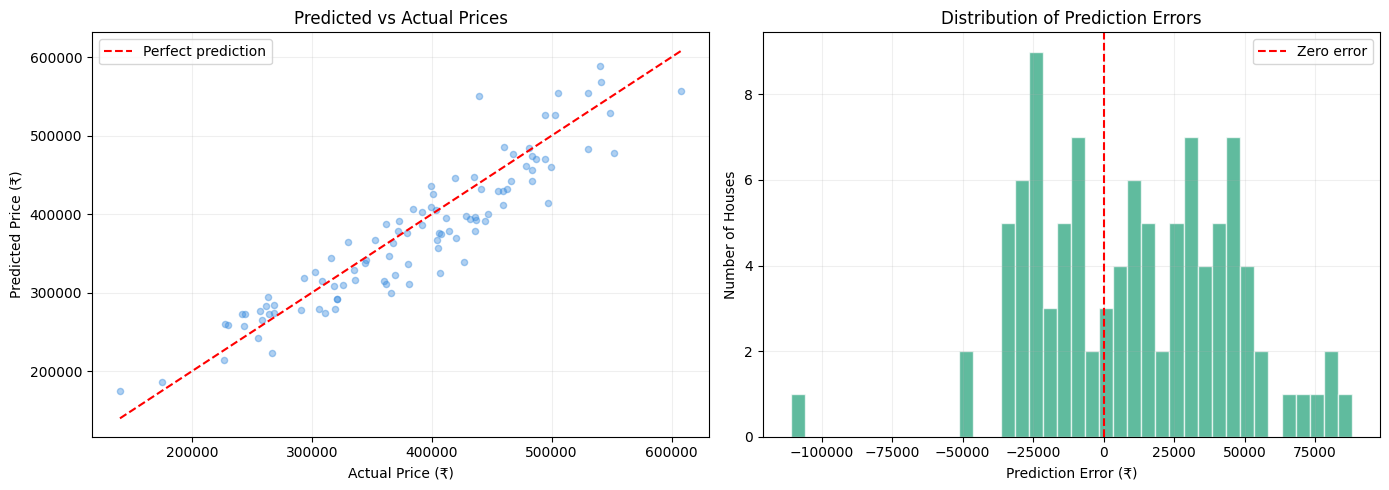

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  CELL 7 — Make Predictions and Evaluate the Model
# ══════════════════════════════════════════════════════════════════

print("=" * 55)
print("  PREDICTIONS & EVALUATION")
print("=" * 55)

# ── Step 1: Predict on TEST set ───────────────────────────────────
y_pred_log = np.dot(X_test, weights)
# Prediction formula: ŷ = X · W
# (100, 12) · (12,) = (100,)
# This gives us 100 PREDICTED log(prices).

y_pred = np.exp(y_pred_log)
# Convert log(price) back to actual price.
# np.exp() is "e to the power of" — the inverse of np.log().
# exp(log(x)) = x   ← this is the fundamental math property we use.

y_true = np.exp(y_test)
# Also convert the true test prices back from log scale.

# ── Step 2: Evaluation Metrics ───────────────────────────────────
print("\n--- Evaluation Metrics ---")

mse = mean_squared_error(y_true, y_pred)
# Mean Squared Error = average of (actual - predicted)²
# We SQUARE the differences so:
#   1. Positive and negative errors don't cancel out
#   2. Large errors are penalised more heavily (squaring amplifies them)
# UNIT: rupees-squared (hard to interpret directly)

rmse = np.sqrt(mse)
# Root Mean Squared Error = sqrt(MSE)
# UNIT: rupees (same as price — more interpretable!)
# "On average, our predictions are off by ₹RMSE"

r2 = r2_score(y_true, y_pred)
# R-squared (Coefficient of Determination)
# = 1 - (variance of errors / variance of true values)
# Interpretation:
#   R² = 1.0 → perfect predictions
#   R² = 0.8 → model explains 80% of price variation
#   R² = 0.0 → model is no better than just predicting the mean price
#   R² < 0   → model is actively WORSE than predicting the mean (bad model!)

mae = np.mean(np.abs(y_true - y_pred))
# Mean Absolute Error = average of |actual - predicted|
# np.abs() takes the absolute value (removes negative signs).
# MAE is simpler to interpret than RMSE and less sensitive to outliers.

print(f"  RMSE (Root Mean Squared Error): ₹{rmse:,.0f}")
print(f"  MAE  (Mean Absolute Error):     ₹{mae:,.0f}")
print(f"  R²   (R-squared score):         {r2:.4f}")
print(f"\n  Interpretation: The model explains {r2*100:.1f}% of house price variation.")
print(f"  On average, predictions are off by ₹{mae:,.0f}")

# ── Step 3: Visualise predictions vs actual prices ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Create 2 side-by-side plots.

# Plot 1: Predicted vs Actual scatter plot
ax1 = axes[0]
ax1.scatter(y_true, y_pred, alpha=0.4, color='#378ADD', s=20)
# scatter() draws dots. Each dot is one house.
# x-axis = true price, y-axis = predicted price
# alpha=0.4 → semi-transparent dots (overlapping dots stay visible)
# s=20 → dot size

min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=1.5, label='Perfect prediction')
# Draw the "perfect prediction line" (diagonal).
# If every prediction were perfect, all dots would sit on this line.
# 'r--' = red dashed line

ax1.set_xlabel('Actual Price (₹)')
ax1.set_ylabel('Predicted Price (₹)')
ax1.set_title('Predicted vs Actual Prices')
ax1.legend()
ax1.grid(True, alpha=0.2)

# Plot 2: Residuals (errors) distribution
residuals = y_true - y_pred
# Residual = actual - predicted for each house.
# Positive residual = we under-predicted (model said cheaper than real)
# Negative residual = we over-predicted (model said pricier than real)
# For a GOOD model, residuals should be small and randomly distributed
# around zero (no systematic pattern).

ax2 = axes[1]
ax2.hist(residuals, bins=40, color='#1D9E75', alpha=0.7, edgecolor='white')
# hist() draws a histogram (bar chart of how often values appear in each range).
# bins=40 → divide the range into 40 bars
# edgecolor='white' → white borders between bars for clarity

ax2.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
# axvline = "axis vertical line". Draws a vertical line at x=0.
# If the histogram is centered on this line, the model is unbiased.

ax2.set_xlabel('Prediction Error (₹)')
ax2.set_ylabel('Number of Houses')
ax2.set_title('Distribution of Prediction Errors')
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  CELL 8 — Predict the price of YOUR custom house
#  This is where it all comes together!
# ══════════════════════════════════════════════════════════════════

print("=" * 55)
print("  PREDICT A CUSTOM HOUSE PRICE")
print("=" * 55)

def predict_house_price(size_sqft, num_bedrooms, num_bathrooms,
                         neigh_score, age_years, dist_km):
    """
    Predicts the price of a house given its features.
    This function applies ALL the same engineering steps we used in training.
    """
    # A Python function defined with 'def'. Parameters are in parentheses.
    # The docstring (triple-quoted text below def) explains what it does.

    # ── Step A: Create a DataFrame with the raw input ────────────
    new_house = pd.DataFrame({
        'size':               [size_sqft],
        'bedrooms':           [num_bedrooms],
        'bathrooms':          [num_bathrooms],
        'neighborhood_score': [neigh_score],
        'house_age':          [age_years],
        'distance_to_city':   [dist_km],
    })
    # We wrap values in [] to create 1-row DataFrames.
    # Without [], pandas would complain about "scalar values".

    # ── Step B: Feature engineering (MUST match training exactly) ─
    new_house['rooms_total'] = new_house['bedrooms'] + new_house['bathrooms']
    new_house['size_per_room'] = new_house['size'] / new_house['rooms_total']
    new_house['price_zone'] = (new_house['neighborhood_score'] >= 7).astype(int)
    # Create the same engineered features as in training.
    # THE GOLDEN RULE: test/prediction data MUST be transformed IDENTICALLY
    # to training data. If you used rooms_total in training, create it here too.

    # ── Step C: Scale using TRAINING statistics ──────────────────
    # CRITICAL: Use the SAME mean and std from training — NOT from this house!
    # Why? Scaling is about the population distribution, not the individual house.
    # If we re-computed mean/std on one house, we'd get nonsense.

    features_to_scale_now = ['size', 'bedrooms', 'bathrooms',
                              'neighborhood_score', 'house_age',
                              'distance_to_city', 'rooms_total',
                              'size_per_room']

    for feature in features_to_scale_now:
        mean = scaled_data[feature]['mean']  # From training data
        std  = scaled_data[feature]['std']   # From training data
        new_house[feature + '_scaled'] = (new_house[feature] - mean) / std

    # ── Step D: Polynomial and interaction features ───────────────
    new_house['size_squared'] = new_house['size_scaled'] ** 2
    new_house['size_x_score'] = new_house['size_scaled'] * new_house['neighborhood_score']

    # ── Step E: Assemble the feature vector ──────────────────────
    x = new_house[feature_columns].values
    # Extract features in the SAME ORDER as training. Order matters for dot product!

    x_with_bias = np.hstack([np.ones((1, 1)), x])
    # Add the bias 1 — same as we did in training.

    # ── Step F: Predict ───────────────────────────────────────────
    log_price_pred = np.dot(x_with_bias, weights)
    # Apply the learned weights.

    predicted_price = np.exp(log_price_pred[0])
    # Convert from log scale back to rupees.
    # [0] extracts the single value from the 1-element array.

    return predicted_price

# ── Test the function with example houses ─────────────────────────
examples = [
    (2200, 4, 3, 8.5, 5,  10.0, "Large new house, great area"),
    (1000, 2, 1, 4.0, 50, 45.0, "Small old house, far from city"),
    (1800, 3, 2, 7.0, 15, 20.0, "Average house, decent area"),
    (3500, 5, 4, 9.5, 2,  5.0,  "Luxury house, near city center"),
]
# A list of tuples. Each tuple = (size, bed, bath, score, age, dist, label)

print(f"\n{'Description':<40} {'Predicted Price':>18}")
print("-" * 60)
for size, bed, bath, score, age, dist, label in examples:
    # Unpack each tuple into individual variables.
    predicted = predict_house_price(size, bed, bath, score, age, dist)
    print(f"{label:<40} ₹{predicted:>15,.0f}")
    # :<40 → left-align, 40 chars wide
    # :>15,.0f → right-align, 15 wide, comma separator, 0 decimals

print("\n✅ Project complete! You built a house price predictor from scratch.")

  PREDICT A CUSTOM HOUSE PRICE

Description                                 Predicted Price
------------------------------------------------------------
Large new house, great area              ₹        617,217
Small old house, far from city           ₹        210,180
Average house, decent area               ₹        456,347
Luxury house, near city center           ₹        753,741

✅ Project complete! You built a house price predictor from scratch.


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  CELL 9 — Summary and Concepts Recap
# ══════════════════════════════════════════════════════════════════

summary = """
╔═══════════════════════════════════════════════════════════╗
║         WHAT YOU BUILT & WHAT YOU LEARNED                 ║
╠═══════════════════════════════════════════════════════════╣
║                                                           ║
║  NUMPY                                                    ║
║  • np.array()     → create arrays from lists              ║
║  • np.dot()       → matrix multiplication                 ║
║  • np.linalg.inv()→ matrix inverse                        ║
║  • np.random.*    → generate random data                  ║
║  • np.exp/log     → transform target variable             ║
║  • Broadcasting   → math on whole arrays at once          ║
║                                                           ║
║  FEATURE ENGINEERING                                      ║
║  • New features   → rooms_total, size_per_room            ║
║  • Standardisation→ z = (x - mean) / std                  ║
║  • Polynomial     → size² captures curved relationships   ║
║  • Interaction    → size × score captures joint effects   ║
║  • Log transform  → handles skewed price distribution     ║
║  • Binary flag    → price_zone from score threshold       ║
║                                                           ║
║  MATRIX OPERATIONS                                        ║
║  • Feature matrix X: shape (n_samples, n_features)        ║
║  • Normal Equation: W = (XᵀX)⁻¹ Xᵀy                      ║
║  • Prediction:     ŷ = X · W (dot product)               ║
║                                                           ║
║  EVALUATION                                               ║
║  • RMSE → typical error in rupees                        ║
║  • MAE  → average absolute error in rupees               ║
║  • R²   → % of variance explained (closer to 1 = better) ║
║                                                           ║
╚═══════════════════════════════════════════════════════════╝
"""
print(summary)


╔═══════════════════════════════════════════════════════════╗
║         WHAT YOU BUILT & WHAT YOU LEARNED                 ║
╠═══════════════════════════════════════════════════════════╣
║                                                           ║
║  NUMPY                                                    ║
║  • np.array()     → create arrays from lists              ║
║  • np.dot()       → matrix multiplication                 ║
║  • np.linalg.inv()→ matrix inverse                        ║
║  • np.random.*    → generate random data                  ║
║  • np.exp/log     → transform target variable             ║
║  • Broadcasting   → math on whole arrays at once          ║
║                                                           ║
║  FEATURE ENGINEERING                                      ║
║  • New features   → rooms_total, size_per_room            ║
║  • Standardisation→ z = (x - mean) / std                  ║
║  • Polynomial     → size² captures curved relationships   ║
║  • In

**Array vs Matrix **— a 1D NumPy array is a vector (one row of numbers). A 2D array is a matrix (a grid of numbers, like a spreadsheet).
Shape — always think (rows, columns). If X.shape is (500, 11), that means 500 houses and 11 features each.
Broadcasting — when you write array * 2, NumPy multiplies every element by 2 without you writing a loop. This is broadcasting.

**Feature engineering** is not cheating — transforming your raw data before training is completely normal and often makes the biggest difference to model quality. Real ML engineers spend most of their time on this, not the model itself.

**The Normal Equation** — the formula W = (XᵀX)⁻¹ Xᵀy looks scary but it's just solving a system of equations using matrices. It finds the weights that minimise prediction error in one shot, with no iterations.

**Train/test split** — never test your model on the same data it trained on. That's like letting a student write the exam questions themselves — it doesn't reveal whether they truly learned anything.